In [1]:
# imports

import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

In [2]:
# Base paths

ROOT = Path("../data/raw/messy_mashup").resolve()

GENRES_PATH = os.path.join(ROOT, "genres_stems")
ESC_PATH = os.path.join(ROOT, "ESC-50-master/audio")
MASHUP_PATH = os.path.join(ROOT, "mashups")


# assert paths exist

assert os.path.exists(GENRES_PATH), f"Genres path {GENRES_PATH} does not exist"
assert os.path.exists(ESC_PATH), f"ESC path {ESC_PATH} does not exist"
assert os.path.exists(MASHUP_PATH), f"Mashup path {MASHUP_PATH} does not exist"

In [3]:
# list genres

genres = sorted(os.listdir(GENRES_PATH))
print(genres)

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [4]:
# count samples per genre

genre_counts = {}
count = 0

for genre in genres:
    for sub_folder in os.listdir(os.path.join(GENRES_PATH, genre)):
        genre_dir = os.path.join(GENRES_PATH, genre, sub_folder)
        files = [f for f in os.listdir(genre_dir) if f.endswith(".wav")]
        count += len(files)
    genre_counts[genre] = count
    count = 0

df_genres = pd.DataFrame(list(genre_counts.items()), columns=["genre","count"])
df_genres

,genre,count
0,blues,400
1,classical,400
2,country,400
3,disco,400
4,hiphop,400
5,jazz,400
6,metal,400
7,pop,400
8,reggae,400
9,rock,400


### Genre Dataset Distribution

- The dataset is **perfectly balanced across genres**, which is ideal for supervised learning.
- Since each genre has the same number of samples, **accuracy and F1-score will be reliable evaluation metrics** without requiring class weighting.


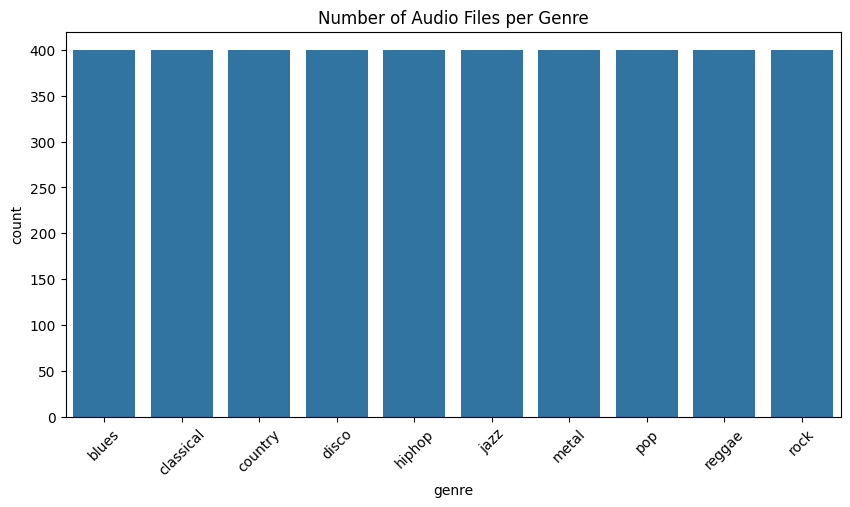

In [5]:
# plot genre distribution

plt.figure(figsize=(10,5))
sns.barplot(data=df_genres, x="genre", y="count")
plt.title("Number of Audio Files per Genre")
plt.xticks(rotation=45)
plt.show()

In [6]:
# audio duration distribution

durations = []

for genre in genres:
    print(f"Processing {genre}...")
    for sub_folder in tqdm(os.listdir(os.path.join(GENRES_PATH, genre))):
        genre_dir = os.path.join(GENRES_PATH, genre, sub_folder)
        for f in os.listdir(genre_dir):
            path = os.path.join(genre_dir, f)
            
            try:
                y, sr = librosa.load(path, sr=None)
                durations.append(librosa.get_duration(y=y, sr=sr))
            except:
                continue

Processing blues...


  0%|          | 0/100 [00:00<?, ?it/s]/home/saber/IITM/DL-GenAI-Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 100/100 [00:07<00:00, 12.55it/s]


Processing classical...


100%|██████████| 100/100 [00:07<00:00, 13.32it/s]


Processing country...


...

100%|██████████| 100/100 [00:08<00:00, 11.46it/s]


Processing reggae...


100%|██████████| 100/100 [00:08<00:00, 11.54it/s]


Processing rock...


100%|██████████| 100/100 [00:08<00:00, 11.60it/s]


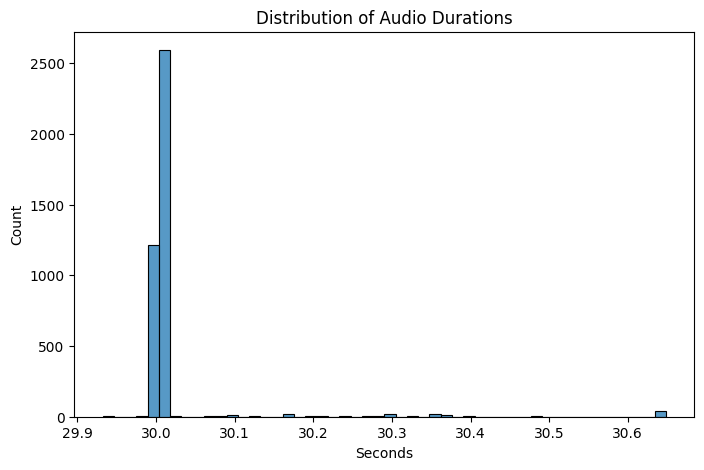

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(durations, bins=50)
plt.title("Distribution of Audio Durations")
plt.xlabel("Seconds")
plt.show()

### Audio Duration Distribution

- Nearly all audio samples have a duration of **approximately 30 seconds**.
- The distribution is highly concentrated around **30 seconds**, with only minor variations.
- This indicates the dataset follows the **standard GTZAN dataset format**, where tracks are clipped to fixed-length segments.

#### Implication for Feature Extraction
Since the audio clips are nearly uniform in duration:
- Feature extraction pipelines (e.g., **MFCC, Mel Spectrograms**) will produce **consistent feature dimensions**.
- Minimal preprocessing will be required for **padding or trimming**.
- This simplifies **batch processing during model training**.


# ESC-50 Data Exploration

In [9]:
meta = pd.read_csv(os.path.join(ROOT, "ESC-50-master/meta/esc50.csv"))
meta.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [13]:
# info

meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  2000 non-null   str  
 1   fold      2000 non-null   int64
 2   target    2000 non-null   int64
 3   category  2000 non-null   str  
 4   esc10     2000 non-null   bool 
 5   src_file  2000 non-null   int64
 6   take      2000 non-null   str  
dtypes: bool(1), int64(3), str(3)
memory usage: 95.8 KB


### ESC-50 Dataset Overview

The ESC-50 dataset contains **2000 labeled environmental sound recordings** distributed across **50 categories**.

Dataset structure:

- Total samples: **2000**
- Categories: **50**
- Samples per class: **40**
- Audio duration: **5 seconds per clip**
- Sample rate: **44.1 kHz**

Each audio file is annotated with the following metadata fields:

| Column | Description |
|------|------|
| filename | Audio file name |
| fold | Cross-validation fold (1–5) |
| target | Numeric class label |
| category | Human-readable class name |
| esc10 | Whether the sample belongs to ESC-10 subset |
| src_file | Original source file ID |
| take | Recording take identifier |

- The dataset is **perfectly balanced**, with **40 samples per category**.
- It covers diverse environmental sounds such as animals, human activities, and mechanical noises.


In [10]:
# Category counts

meta['category'].value_counts()

category
dog                 40
chirping_birds      40
vacuum_cleaner      40
thunderstorm        40
door_wood_knock     40
can_opening         40
crow                40
clapping            40
fireworks           40
chainsaw            40
airplane            40
mouse_click         40
pouring_water       40
train               40
sheep               40
water_drops         40
church_bells        40
clock_alarm         40
keyboard_typing     40
wind                40
footsteps           40
frog                40
cow                 40
brushing_teeth      40
car_horn            40
crackling_fire      40
helicopter          40
drinking_sipping    40
rain                40
insects             40
laughing            40
hen                 40
engine              40
breathing           40
crying_baby         40
hand_saw            40
coughing            40
glass_breaking      40
snoring             40
toilet_flush        40
pig                 40
washing_machine     40
clock_tick          40
sn

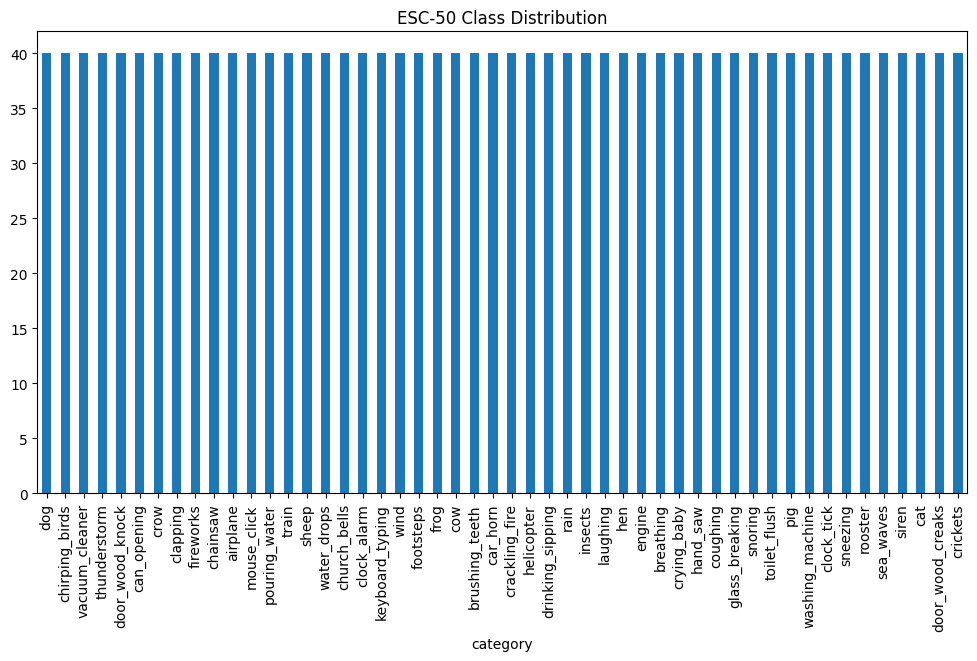

In [12]:
# plot category distribution

plt.figure(figsize=(12,6))
meta['category'].value_counts().plot(kind="bar")
plt.title("ESC-50 Class Distribution")
plt.show()

In [14]:
# count mashups

mashups = [f for f in os.listdir(MASHUP_PATH) if f.endswith(".wav")]
len(mashups)

3020

### Mashup Dataset

The mashup dataset contains **3020 audio files**.

- Mashups consist of **combinations of musical stems and environmental sounds**.
- Most mashup clips have durations close to **30 seconds**, similar to the original genre dataset.
- However, the duration histogram shows **greater variability**, with some clips shorter than 30 seconds.

#### Implication for Preprocessing
Since mashup durations vary slightly:
- Audio samples may need **padding or trimming** to ensure consistent input length.
- This will be handled during the **dataset preprocessing stage**.

The mashup dataset represents the **core task of the project**, where models must learn to analyze complex audio mixtures containing both **music and environmental sound components**.

In [15]:
# mashup duration distribution

mashup_durations = []

for f in tqdm(mashups):
    path = os.path.join(MASHUP_PATH, f)
    
    try:
        y, sr = librosa.load(path, sr=None)
        mashup_durations.append(librosa.get_duration(y=y, sr=sr))
    except:
        continue

100%|██████████| 3020/3020 [00:05<00:00, 504.49it/s]


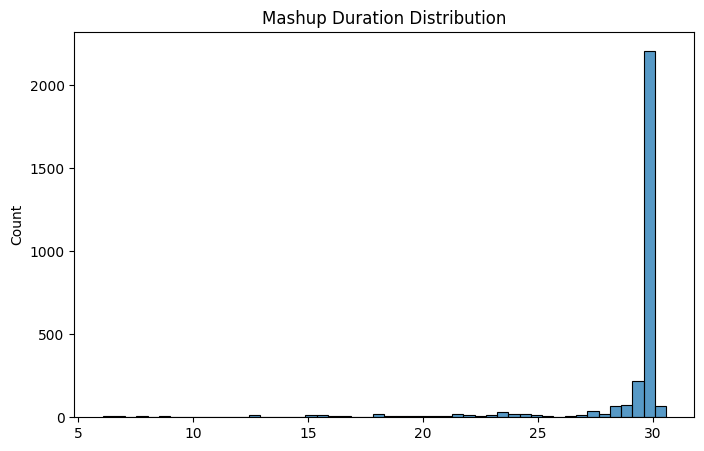

In [17]:
# plot mashup duration distribution

plt.figure(figsize=(8,5))
sns.histplot(mashup_durations, bins=50)
plt.title("Mashup Duration Distribution")
plt.show()

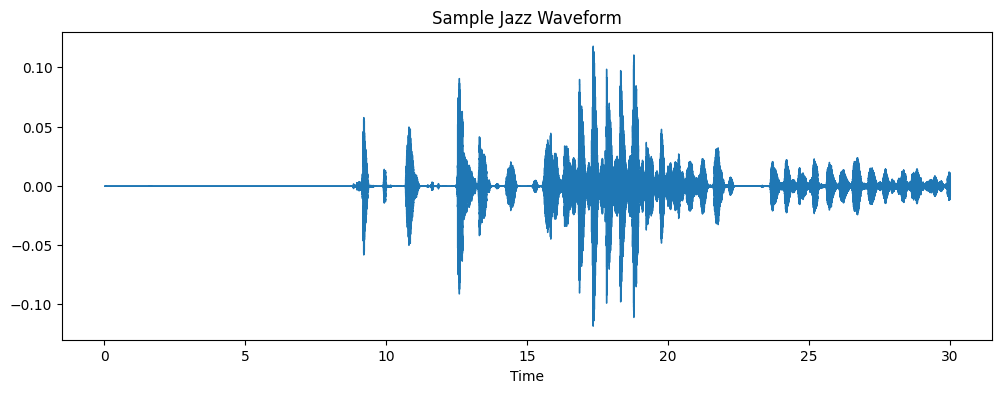

In [32]:
# sample visualization

sample_file = os.path.join(GENRES_PATH, "jazz", "jazz.00000", "bass.wav")

y, sr = librosa.load(sample_file)

plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)
plt.title("Sample Jazz Waveform")
plt.show()

### Sample Waveform Visualization

The waveform above represents a **bass stem from a jazz track**.

- The waveform shows variations in amplitude corresponding to **musical notes and rhythmic patterns**.
- Periods of lower amplitude indicate **quieter sections or pauses** in the audio.
- Higher peaks correspond to **strong bass notes or transients**.

Waveform analysis provides a **time-domain representation of audio signals**, allowing us to observe:

- Amplitude variations
- Rhythmic structure
- Transient events

However, waveforms alone do not clearly reveal **frequency characteristics**, which are essential for musical analysis.

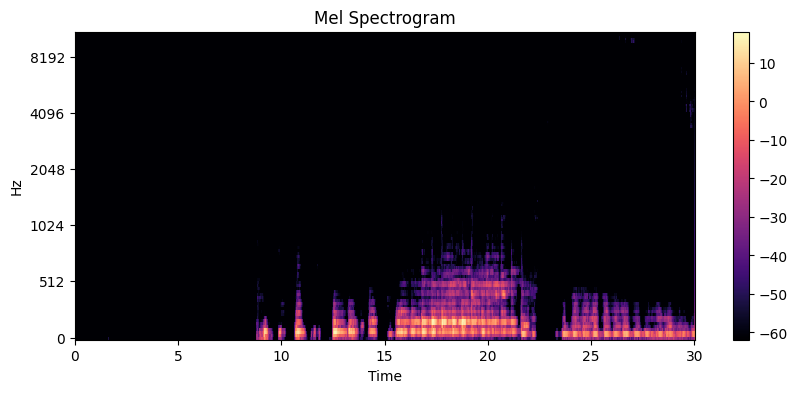

In [33]:
# spectogram

S = librosa.feature.melspectrogram(y=y, sr=sr)

plt.figure(figsize=(10,4))
librosa.display.specshow(librosa.power_to_db(S), sr=sr, x_axis="time", y_axis="mel")
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

### Mel Spectrogram Representation

The Mel spectrogram visualizes the **frequency content of the audio signal over time**.

- Brighter regions represent **higher energy frequencies**.
- The bass stem primarily occupies **lower frequency bands**, which is expected for bass instruments.
- Temporal patterns correspond to **rhythmic note events**.

The Mel scale approximates **human auditory perception**, making it particularly useful for machine learning models in audio tasks.
